# Анализ аудитории витуберов

#### Импорт всего нужного

In [1]:
import sys
sys.path.insert(1, '../util/')

from data import UserData, FollowerData
from userdata import get_userdata, get_userdata_by_login
from followers import get_followers

import numpy as np
import os
import csv
from datetime import datetime
from typing import Optional, List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor, as_completed

## Грузим фолловеров у витуберов

In [2]:
VTUBERS_LIST_FILE_PATH = "./data/vtubers.txt"
VTUBERS = set()

with open(VTUBERS_LIST_FILE_PATH, 'r') as data_file:
    for line in data_file.readlines():
        if line.startswith("#"): # comment:
            continue
        VTUBERS.add(line.lower().strip())

In [ ]:
# Check if all vtubers exists
counter = 0
for vtuber in VTUBERS:
    counter += 1
    print(f"[{counter}/{len(VTUBERS)}] Check vtuber {vtuber}")
    assert get_userdata_by_login(vtuber) is not None

In [3]:
print(f"Loaded {len(VTUBERS)} vtubers")

Loaded 216 vtubers


### Онлайн загрузка

In [4]:
NUM_WORKERS = 16 # Set up for your processor and to prevent from ddos protection
FAIL_REPEATS = 5

def load_followers_execution(vtuber_login: str) -> Tuple[str, Optional[List[FollowerData]]]:
    for i in range(FAIL_REPEATS):
        result = get_followers(vtuber_login)
        if result is None:
            print("[ERROR]", "Failed loading vtuber", vtuber_login, "attempt", i)
        else:
            return vtuber_login, result
    return vtuber_login, None


# Fast load
vtuber_followers = {}
with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = []

    for vtuber in VTUBERS:
        future = executor.submit(load_followers_execution, vtuber_login=vtuber)
        futures.append(future)
    
    for future in as_completed(futures):
        vtuber_login, followers_result = future.result()
        if followers_result is None:
            print(f"Cannot load `{vtuber_login}` result")
        else:
            empty_results = list(filter(lambda el: el.user is None, followers_result))
            print(f"Got `{vtuber_login}` result, empty results: {len(empty_results)}/{len(followers_result)}")
        vtuber_followers[vtuber_login] = followers_result

moonspidy : 0
higanbanban : 0
qchaan_9 : 0
okibooka : 0
severinasoda : 0
kirishiba : 0
cinaminnie : 0
fumm_y : 0
snezha_mrr : 0
hatome : 0
llestock : 0
xjaily : 0
starless_hel : 0
kwakusha228 : 0
hattiezazu : 0
holographicvt : 0
okibooka : 50
snezha_mrr : 50
higanbanban : 50
moonspidy : 50
hatome : 50
cinaminnie : 50
llestock : 50
xjaily : 50
holographicvt : 50
hattiezazu : 50
kirishiba : 50
kwakusha228 : 50
starless_hel : 50
fumm_y : 50
severinasoda : 50
qchaan_9 : 50
okibooka : 100
llestock : 100
higanbanban : 100
cinaminnie : 100
hatome : 100
moonspidy : 100
snezha_mrr : 100
starless_hel : 100
holographicvt : 100
hattiezazu : 100
kirishiba : 100
kwakusha228 : 100
fumm_y : 100
xjaily : 100
qchaan_9 : 100
severinasoda : 100
okibooka : 150
higanbanban : 150
cinaminnie : 150
hatome : 150
llestock : 150
snezha_mrr : 150
kwakusha228 : 150
hattiezazu : 150
moonspidy : 150
holographicvt : 150
kirishiba : 150
fumm_y : 150
xjaily : 150
starless_hel : 150
qchaan_9 : 150
severinasoda : 150
okib

In [6]:
for vtuber in VTUBERS:
    assert vtuber_followers[vtuber] is not None

### Кеширование результатов

In [16]:
def get_cache_path():
    current_date = datetime.now()

    return os.path.join("data/", 
                        ".temp/",
                        f"followers_{current_date.year}_{current_date.month}_{current_date.day}.txt")

In [25]:
def cache_followers_data(vtuber_followers: Dict[str, List[FollowerData]]):
    with open(get_cache_path(), 'w') as cache_file:
        csvwriter = csv.writer(cache_file, delimiter=',')
        csvwriter.writerow(["vtuber",
                            "followed_at",
                            "id",
                            "login",
                            "created_at",
                            "deleted_at",
                            "follows_count"])

        for (vtuber, value) in vtuber_followers.items():
            for follower_data in value:
                if follower_data.user is None:
                    csvwriter.writerow([vtuber,
                                        follower_data.followed_at,
                                        "",
                                        "",
                                        "",
                                        "",
                                        ""])
                else:
                    csvwriter.writerow([vtuber,
                                        follower_data.followed_at,
                                        follower_data.user.id,
                                        follower_data.user.login,
                                        str(follower_data.user.created_at),
                                        str(follower_data.user.deleted_at),
                                        follower_data.user.follows_count])

In [26]:
cache_followers_data(vtuber_followers)

#### Загрузка закешированных результатов

In [27]:
def load_followers_cache(filepath: str) -> Dict[str, List[FollowerData]]:
    result = {}

    with open(filepath, 'r') as cache_file:
        csvreader = csv.DictReader(cache_file, delimiter=',')

        for row in csvreader:
            vtuber = row['vtuber']
            followed_at = datetime.fromisoformat(row['followed_at'])
            if row['id']:
                id              = int(row['id'])
                login           = None if row['login'] == "None" else row['login']
                created_at      = None if row['created_at'] == "None" else datetime.fromisoformat(row['created_at'])
                deleted_at      = None if row['deleted_at'] == "None" else datetime.fromisoformat(row['deleted_at'])
                follows_count   = int(row['follows_count'])
                user_data = UserData(id=id,
                                     login=login,
                                     created_at=created_at,
                                     deleted_at=deleted_at,
                                     follows_count=follows_count)
            else:
                user_data = None
            follower_data = FollowerData(user=user_data,
                                         followed_at=followed_at)
            
            if vtuber not in result.keys():
                result[vtuber] = []
            result[vtuber].append(follower_data)
    
    return result

## Обрабатываем полученные данные

In [28]:
data = load_followers_cache("./data/.temp/followers_2025_11_1.txt")

In [29]:
print("vtuber,followers,existing_followers")
for (vtuber, followers) in data.items():
    print(vtuber, len(followers), len(list(filter(lambda el: el.user is not None, followers))), sep=",")

vtuber,followers,existing_followers
fumm_y,937,937
okibooka,1709,1709
holographicvt,1810,1810
starless_hel,1926,1926
hatome,2129,2128
kwakusha228,2443,2442
nesaga_micune,729,729
hattiezazu,3080,3079
moonspidy,3557,3557
llestock,3453,3450
kirishiba,3741,3740
cinaminnie,3820,3819
satu_ris,1706,1705
tomoesin,3919,3917
izumee,3018,3017
manyamillio,1189,1189
squimeh,3767,3764
crabcyborg,2403,2403
nkors,2679,2678
aurora_project,1306,1306
konekoari,3245,3245
xjaily,6087,6086
miruku_hoshi,4624,4623
aoihinodevt,2717,2714
echidnaya,3593,3593
tischhhh,3375,3374
goosekina,3159,3158
snezha_mrr,9782,9780
usbsushi,3591,3589
arr1su,1443,1441
amalia_goddes,4580,4578
v_o_r_o_b,2894,2891
axilissa,1230,1230
vwenya,3640,3637
bready_xo,5511,5497
megubite,4301,4301
haruweichan,1288,1288
d_e_l_y,1121,1121
amikirisan,8414,8406
iris_ti,3613,3612
k0tava,2386,2385
higanbanban,13196,13194
fluffypaww,4385,4383
amy_vangersert,4487,4486
lainlian,4484,4483
hovvney,1394,1394
mad_demian,4519,4513
ezdedus,1279,1279
bkdth

In [30]:
# Check if data is complete
for vtuber in VTUBERS:
    assert vtuber in data.keys(), vtuber

### Анализ аудитории

In [31]:
import matplotlib.pyplot as plt

#### Анализ подписок

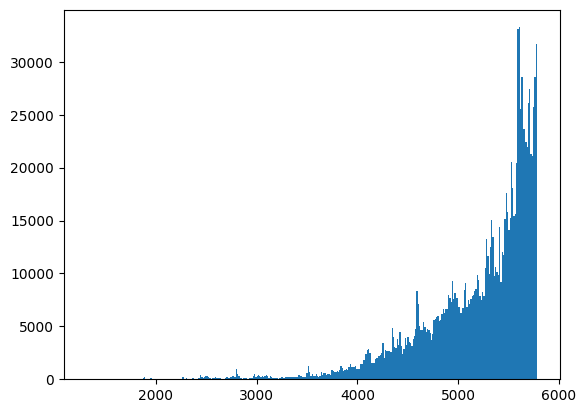

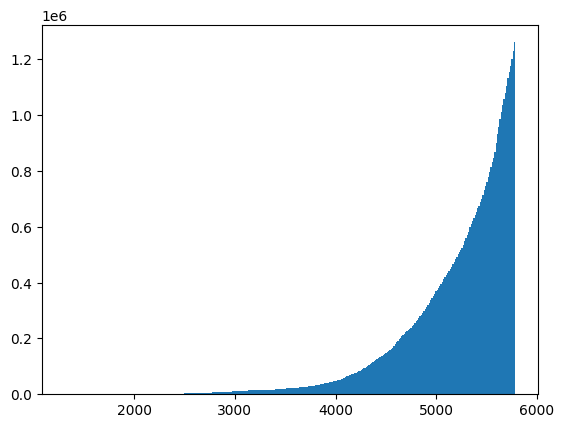

In [32]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 
plt.hist(auditory_data, bins="auto", log=False, cumulative=True)
plt.show() 

Тенденция к росту, однозначно, есть.

Хотя есть два момента, которые очень инетересные, первый около 4600 дня, второй - с апреля этого года.

* Первый обусловлен следующим: `yumekomoore` и `sati_akura` резко взлетели
* Второй обусловлен следующим: `xKamysh` резко взлетела 

#### Пруф для первого момента

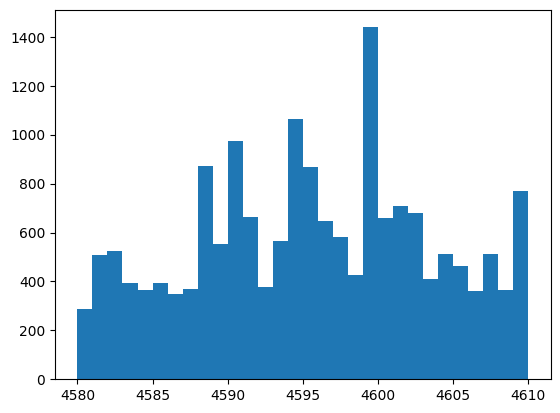

In [33]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False, range=(4580, 4610))
plt.show() 

In [34]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append((vtuber, follower))

auditory_data = list(filter(lambda viewer: (viewer[1].followed_at - sunce_date).days in range(4580, 4610), auditory_data))
counters = {}
for dt in auditory_data:
    counters[dt[0]] = counters.get(dt[0], 0) + 1
print(auditory_data[100][1].followed_at)

for (k, v) in sorted(counters.items(), key=lambda el: el[1], reverse=True)[:10]:
    print(k, v)

2022-07-29 16:07:47+00:00
yumekomoore 3524
sati_akura 3308
kurisu 1585
quinella_admin 713
nyamuras 438
vernirra 381
fropsya 307
holographicvt 299
moereira 289
mamilokuchii 280


#### Пруф для второго момента

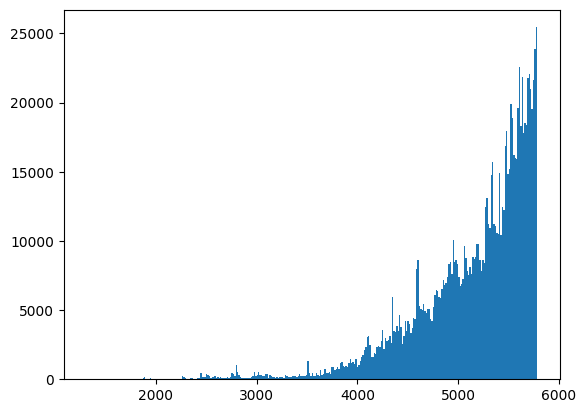

In [35]:
IGNORED_VTUBERS = ['xkamysh', 'qchaan_9', 'rera_seal']

sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in VTUBERS:
    if vtuber in IGNORED_VTUBERS:
        continue
    
    followers = data[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Анализ роста аудитории

Счетчик уникальных фолловов (то есть не учитываются второй, третий и т.д. фолловы от одного и того же человека)

In [40]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = {}
for vtuber in VTUBERS:
    followers = data[vtuber]
    for follower in followers:
        if follower.user is not None:
            if follower.user.login not in auditory_data.keys():
                auditory_data[follower.user.login] = follower.followed_at
            auditory_data[follower.user.login] = min(auditory_data[follower.user.login], follower.followed_at)

auditory_data = auditory_data.values()
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

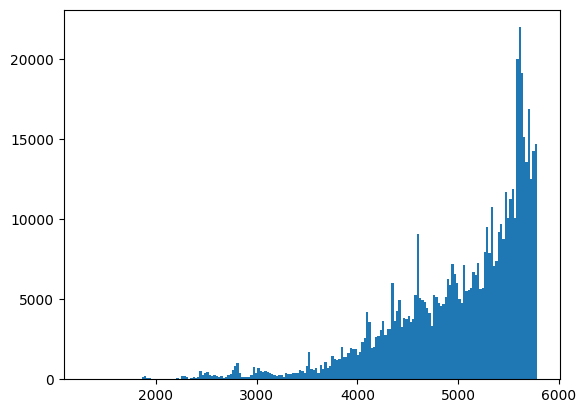

In [41]:
plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Уникальность витуберов

Посмотрим, какая часть аудитории витубера смотрит только его 

In [44]:
follows_by_user = {}
for vtuber in VTUBERS:
    for follow_data in data[vtuber]:
        if follow_data.user is not None:
            if follow_data.user.login not in follows_by_user.keys():
                follows_by_user[follow_data.user.login] = []    
            follows_by_user[follow_data.user.login].append((vtuber, follow_data))
print(len(follows_by_user.keys()))

576908


In [45]:
unique_users = list(filter(lambda fd: len(fd[1]) <= 1, follows_by_user.items()))
print(len(unique_users))

416590


In [46]:
vtuber_unique_followers_counter = {}
for (user, following) in unique_users:
    vtuber_name = following[0][0]
    vtuber_unique_followers_counter[vtuber_name] = vtuber_unique_followers_counter.get(vtuber_name, 0) + 1
for (k, v) in sorted(vtuber_unique_followers_counter.items(), key=lambda el: el[1] / len(data[el[0]]), reverse=True)[:20]:
    print(k, f"{v}/{len(data[k])}", f"{v * 100 // len(data[k])}%")

mad_demian 3846/4519 85%
bready_xo 4611/5511 83%
natakodo 18115/22056 82%
lastglance_ 3359/4249 79%
gishichi 882/1264 69%
henmimori 2690/3982 67%
kashtan_mp4 2030/3014 67%
nyapuru 8568/12733 67%
mukubae 1572/2428 64%
boopa 8455/13381 63%
ananastya_nastya 6489/10563 61%
amikirisan 5154/8414 61%
piwochan 3932/6484 60%
linamyth 4572/7540 60%
naxajlka 2135/3587 59%
lightfoxmanga 4894/8299 58%
quinella_admin 8823/15402 57%
vernirra 10494/18473 56%
planyach 26105/46442 56%
nekisekai 7099/12848 55%


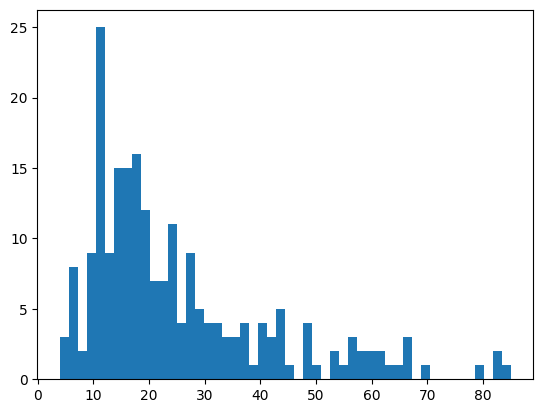

In [47]:
plt.hist(list(map(lambda el: int(el[1] * 100 / len(data[el[0]])), vtuber_unique_followers_counter.items())), bins=50)
plt.show()

| Vtuber | Statistics | Description |
| --- | --- | --- |
| mad_demian | 3855/4519 85% | в хиатусе |
| bready_xo | 4625/5512 83% | в хиатусе |
| natakodo | 18171/22059 82% | в хиатусе |
| lastglance_ | 3371/4250 79% | в хиатусе |
| gishichi | 886/1264 70% | англо витубер??? |
| kashtan_mp4 | 2030/2982 68% | Ich weiß nicht |
| nyapuru | 8657/12733 67% | мужыыыыык |
| mukubae | 1613/2429 66% | в хиатусе |
| boopa | 8545/13370 63% | Ich weiß nicht |
| linamyth | 4732/7542 62% | в хиатусе |
| ananastya_nastya | 6511/10562 61% | Лига легендер |
| amikirisan | 5176/8408 61% | Ich weiß nicht |
| piwochan | 3942/6485 60% | Ich weiß nicht |
| naxajlka | 2142/3588 59% | Ich weiß nicht |
| lightfoxmanga | 4903/8276 59% | мужыыыыык |
| quinella_admin | 8864/15398 57% | Ich weiß nicht |
| vernirra | 10568/18474 57% | Ich weiß nicht |
| planyach | 26256/46423 56% | Ich weiß nicht |
| nekisekai | 7131/12849 55% | Ich weiß nicht |
| nnstreamercha | 2546/4724 53% | мужыыыыык |
| mamilokuchii | 8751/17174 50% | Лигалегендер, любимый у дедпи |
| yumekomoore | 15773/31344 50% | Ich weiß nicht |

In [48]:
import plotly.express as px
import pandas as pd

uniqueness_data = np.array(list(vtuber_unique_followers_counter.items()))
follower_counts_data = np.array([len(data[vtuber]) for vtuber in uniqueness_data[:, 0]])
unique_followers_count_data = uniqueness_data[:, 1].astype("int")
unique_followers_count_percentage_data = unique_followers_count_data * 100 / follower_counts_data
df = pd.DataFrame({
    "x": follower_counts_data,
    "y": unique_followers_count_percentage_data,
    "vtuber": uniqueness_data[:, 0]
})
fig = px.scatter(df, x="x", y="y", hover_name="vtuber")
fig.show()

### Кластеризация витуберов

#### Векторизация данных

In [51]:
VTUBER_EMBEDDINGS_SIZE = len(follows_by_user.keys())
VTUBER_EMBEDDINGS_INDEX_MAP = {}
for (index, embedding) in zip(range(VTUBER_EMBEDDINGS_SIZE), list(follows_by_user.keys())):
    VTUBER_EMBEDDINGS_INDEX_MAP[embedding] = index


def vtuber2vec(vtuber: str) -> np.ndarray:
    result = np.zeros(VTUBER_EMBEDDINGS_SIZE)
    for follower_data in data[vtuber]:
        if follower_data.user is not None:
            result[VTUBER_EMBEDDINGS_INDEX_MAP[follower_data.user.login]] = 1.0
    
    return result

In [52]:
vtuber_vectors = {}
for vtuber in VTUBERS:
    vtuber_vectors[vtuber] = vtuber2vec(vtuber)

dataset = []
for vtuber in VTUBERS:
    dataset.append(vtuber_vectors[vtuber])
dataset = np.array(dataset)

#### Кластеризация и отрисвка

In [53]:
import plotly.express as px
import pandas as pd
import sklearn

##### Косинусное расстояние

In [54]:
labels = sklearn.cluster.HDBSCAN(min_cluster_size=2, max_cluster_size=100, metric="cosine").fit_predict(X=dataset)

In [55]:
projection = sklearn.manifold.TSNE(metric="cosine", random_state=123).fit_transform(dataset)

In [56]:
data_frame = pd.DataFrame({
    "x": projection[:, 0],
    "y": projection[:, 1],
    "Кластер": labels,
    "Имя": list(VTUBERS)
})
data_frame["Кластер"] = data_frame["Кластер"].astype(str) #convert to string

In [57]:
fig = px.scatter(data_frame, 
                 x="x", 
                 y="y",
                 color="Кластер", 
                 hover_name="Имя")
fig.show()